# Generating CDFs

Most distributions are discovered by being curious about the world. Someone watches a phenomenon unfold, asks what mechanism could generate it, and then recognizes the mathematical pattern. It's good to remember that math is discovered, not invented.

In each of the following parts, there is a description of a simulation. Each of these simulations generates one of the following distributions, along with its name in `scipy.stats`:

| Distribution | SciPy PDF/PMF                               | SciPy CDF                                   | Parameters                          |
| ------------ | ------------------------------------------- | ------------------------------------------- | ----------------------------------- |
| Beta         | `beta.pdf(x, a, b)`                         | `beta.cdf(x, a, b)`                         | $(a,b)$                             |
| Pareto       | `pareto.pdf(x, b, scale=xm)`                | `pareto.cdf(x, b, scale=xm)`                | shape $b$, minimum $x_m$ |
| Uniform      | `uniform.pdf(x, loc=a, scale=b-a)`          | `uniform.cdf(x, loc=a, scale=b-a)`          | lower $a$, upper $b$            |
| Lognormal    | `lognorm.pdf(x, s=sigma, scale=np.exp(mu))` | `lognorm.cdf(x, s=sigma, scale=np.exp(mu))` | $\log X\sim N(\mu,\sigma^2)$      |
| Normal       | `norm.pdf(x, loc=mu, scale=sigma)`          | `norm.cdf(x, loc=mu, scale=sigma)`          | $(\mu,\sigma)$                      |
| Exponential  | `expon.pdf(x, scale=1/lam)`                 | `expon.cdf(x, scale=1/lam)`                 |  $\lambda$                   |


For parts 1-8 below, program and run the described simulation, plot its distribution using the ECDF, and compare with the distributions above.

Which simulations generate which CDFs?

# **Pick four simulations to complete. You do not have to do all of them.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(5012)

**Q1.**

OK, a warm-up, just to get started.

1. Set up a grid of $K$ equally spaced values between 0 and 1, `{1/K, 2/K, ..., K/K}`.
2. Draw a point from the grid at random with equal probability.
3. For a very small $K$, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase $K$?

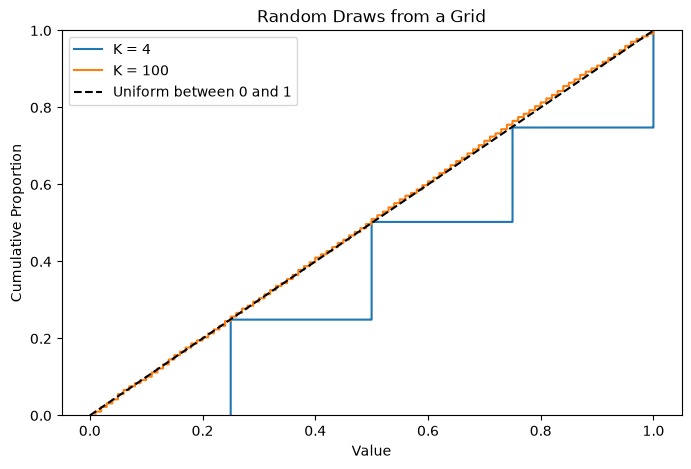

In [2]:
# My 1.1, 1.2, and 1.3 Code

n = 5_000
plt.figure(figsize=(8, 5))

for K in [4, 100]:
    grid_values = np.arange(1, K + 1) / K
    sampled_values = rng.choice(grid_values, size=n)
    sns.ecdfplot(x=sampled_values, label=f"K = {K}")

plot_values = np.linspace(0, 1, 500)
plt.plot(plot_values, stats.uniform.cdf(plot_values, loc=0, scale=1), "k--", label="Uniform between 0 and 1")
plt.xlabel("Value")
plt.ylabel("Cumulative Proportion")
plt.title("Random Draws from a Grid")
plt.legend()
plt.show()

1.4

As K increases, the distribution gets closer to being uniform between 0 and 1. With more equally spaced values to choose from, the jumps in the ECDF become smaller and the graph gets closer to the straight line of the uniform CDF.

**Q2.** 

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

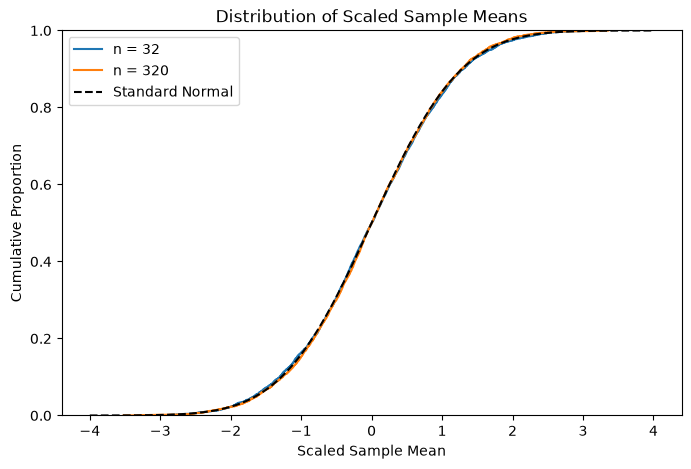

In [3]:
# My 2.1, 2.2, and 2.3 Code

b = 5_000
plt.figure(figsize=(8, 5))

for n in [32, 320]:
    scaled_sample_means = []

    for _ in range(b):
        sample_values = rng.uniform(-np.sqrt(3), np.sqrt(3), size=n)
        scaled_sample_mean = np.sqrt(n) * sample_values.mean()
        scaled_sample_means.append(scaled_sample_mean)

    sns.ecdfplot(x=scaled_sample_means, label=f"n = {n}")

plot_values = np.linspace(-4, 4, 500)
plt.plot(plot_values, stats.norm.cdf(plot_values, loc=0, scale=1), "k--", label="Standard Normal")
plt.xlabel("Scaled Sample Mean")
plt.ylabel("Cumulative Proportion")
plt.title("Distribution of Scaled Sample Means")
plt.legend()
plt.show()

2.4

As n increases, the sample means multiplied by the square root of n approach a standard normal distribution, which has mean 0 and variance 1. The ECDFs are already close to the standard normal CDF.

**Q3.** 

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability $p$, and we want to study the distribution of the survivors. 

1. Flip `n = 40` coins, which each come up heads with probability $p = 1/2$ and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, `n * p`.
3. Divide by the standard deviation `sqrt( n * p * (1-p) )`.
4. Repeat the above process `b = 5_000` times and plot the ECDF.
5. What distribution does this approach as $n$ increases?
6. How do the results change as you adjust $p$?

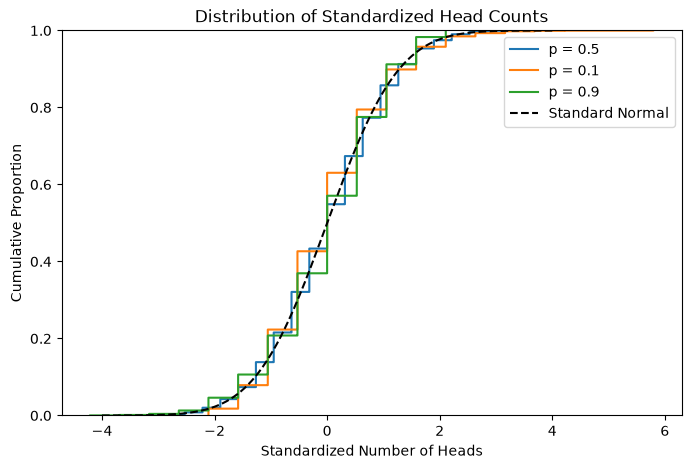

In [4]:
# My 3.1, 3.2, 3.3, and 3.4 Code

n = 40
b = 5_000

plt.figure(figsize=(8, 5))

for p in [0.5, 0.1, 0.9]: 
    standardized_head_counts = []
    expected_head_count = n * p
    head_count_std = np.sqrt(n * p * (1 - p))

    for _ in range(b):
        head_count = (rng.random(n) < p).sum()
        standardized_head_count = ((head_count - expected_head_count) / head_count_std)
        standardized_head_counts.append(standardized_head_count)

    sns.ecdfplot(x=standardized_head_counts, label=f"p = {p}")

plot_values = np.linspace(-4, 4, 500)
plt.plot(plot_values, stats.norm.cdf(plot_values, loc=0, scale=1), "k--", label="Standard Normal")
plt.xlabel("Standardized Number of Heads")
plt.ylabel("Cumulative Proportion")
plt.title("Distribution of Standardized Head Counts")
plt.legend()
plt.show()

3.5

As n increases, the adjusted head counts approach a standard normal distribution, as long as p stays fixed between 0 and 1. Subtracting the expected count centers the values at 0, and dividing by the standard deviation gives them a variance of 1.

3.6

With 40 flips, the results match the normal CDF more closely when p = 0.5. When p = 0.1, the distribution has a longer tail toward higher values. When p = 0.9, it has a longer tail toward lower values. When p is close to 0 or 1, more flips are needed for the distribution to look approximately normal.

**Q4.** 

A process is running in discrete time. In each time interval of length `dt`, it terminates with probability `r * dt`, where `r * dt < 1`. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as $dt$ goes to zero?
5. How do the results change as you adjust $r$?

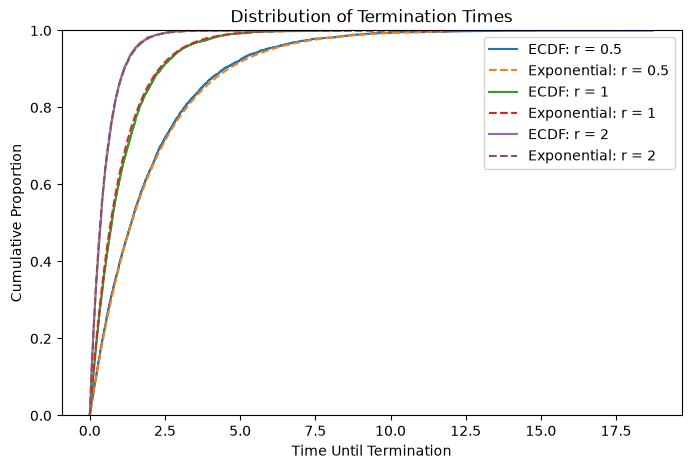

In [5]:
# My 4.1, 4.2, and 4.3 Code

n = 5_000
dt = 1e-3

plot_values = np.linspace(0, 12, 500)
plt.figure(figsize=(8, 5))

for r in [0.5, 1, 2]:
    termination_times = []
    termination_probability = r * dt

    for _ in range(n):
        period_count = 1
        while rng.random() >= termination_probability:
            period_count += 1

        termination_time = period_count * dt
        termination_times.append(termination_time)

    sns.ecdfplot(x=termination_times, label=f"ECDF: r = {r}")
    plt.plot(plot_values, stats.expon.cdf(plot_values, scale=1 / r), "--", label=f"Exponential: r = {r}")

plt.xlabel("Time Until Termination")
plt.ylabel("Cumulative Proportion")
plt.title("Distribution of Termination Times")
plt.legend()
plt.show()

4.4

As dt gets closer to 0, the time until termination approaches an exponential distribution with rate r. The matching SciPy distribution uses scale=1/r.

4.5

A larger r means the process is more likely to end during each time interval, so waiting times are shorter and the CDF rises faster. A smaller r means longer waiting times. The expected waiting time is 1/r, so rates of 0.5, 1, and 2 give expected waiting times of 2, 1, and 0.5.

**Q5.** 

We're going to draw a sample of values, sort them, and track a particular rank. This is particularly useful for understanding **extreme events**: We might be interested in the behavior of the biggest storm or earthquake each year, but be working with a dataset about storms in general over 25 or 50 years. 

1. Draw $K=20$ values from `Uniform[0, 1]`.
2. Sort them by size from smallest to largest.
3. Record the largest value.
4. Repeat `n` times and plot the ECDF.
5. Repeat the previous steps for each rank from 1 to $K$.
6. What distribution(s) does this process generate? How does the distribution depend on the rank?

**Q6.**

Many things in the world grow through a long sequence of small proportional gains and losses: prices bounce around in response to information, tumors grow and shrink, populations expand and contract. When those tiny changes accumulate randomly over time, they produce recognizable patterns.

1. Start at a state of `1`.
2. Split a unit of time into $1/\Delta$ small time steps. Start with $\Delta = 1/100$, so $\{0, 1/100, 2/100, ... 99/100\}$.
3. Each period, the state is multiplied by $u = exp(\sqrt{\Delta})$ with probability $p=1/2$ or multiplied by $d = exp(-\sqrt{\Delta})$ with probability $1-p=1/2$.
4. Repeat steps 1-3 `B = 1_000` times and record the final position, and plot the ECDF of your sample.
5. What distribution does this approach as $\Delta$ gets close to zero?

**Q7.**

A surprising regularity appears again and again in human populations: the second-largest city is often roughly half the size of the largest, the third-largest roughly one-third the size, and so on. This relationship is called Zipf's law, and it connects the rank of an observation to its size.

1. Suppose there are `K = 100_000` cities, ranked from largest to smallest. Create the ranks $r= \{ 1,..., K\}$.
2. Zipf's law says that the size of the city with rank $r$ is proportional to
$ 
x_r = \left(K/r \right)^s. 
$
Start with $s=1$.
3. Randomly sample `n=5_000` ranks, with each rank equally likely, and record the corresponding sizes.
4. Plot the ECDF of the simulated sizes.
5. What distribution does this generate as $K$ becomes large?
6. How does the distribution change as you adjust $s$?

**Q8.**

Imagine a toy model of a collection of particles constantly colliding and exchanging energy, while the total amount of energy in the system remains fixed. No particle keeps its energy forever: repeated random exchanges eventually produce a stable distribution even though every individual particle continues to change.

1. Initialize `n = 1_000` particles with energy $E_i=1$.
2. Randomly choose two particles $i$ and $j$. Add their energies, $ E = E_i + E_j$ .
3. Draw a uniformly distributed number from between 0 and 1, $u$ and redistribute the energy: $ E_i = uE$ and $E_j=(1-u)E. $
4. Repeat this random exchange `b=1_000_000` times.
5. Record the final energies of all particles and plot their ECDF.
6. What distribution does this simulation approach as $n$ becomes large?
7. How does the distribution change if you increase or decrease the initial energy for each particle?